Loading data...
  studentInfo       : 32,593 rows
  studentAssessment : 173,912 rows
  studentRegistration: 32,593 rows
  assessments       : 206 rows
  Overall dropout rate: 31.2%

A1: Base feature encoding...
  Base encodings complete.

A2: Engineering assessment features...
  Assessment features added:
    mean_score, std_score, n_assessments
    mean_days_early, first_score, pct_submitted

A3: Engineering registration timing features...
  Registration features added: days_to_start, late_registration

A4: Creating interaction terms...
  Interaction terms added:
    edu_x_imd, attempts_x_score, age_x_credits, first_score_x_n

A5: Final feature set — 19 features:
   1. gender_enc
   2. age_enc
   3. edu_enc
   4. imd_enc
   5. disab_enc
   6. num_of_prev_attempts
   7. studied_credits
   8. mean_score
   9. std_score
  10. n_assessments
  11. pct_submitted
  12. mean_days_early
  13. first_score
  14. days_to_start
  15. late_registration
  16. edu_x_imd
  17. attempts_x_score
  18. a

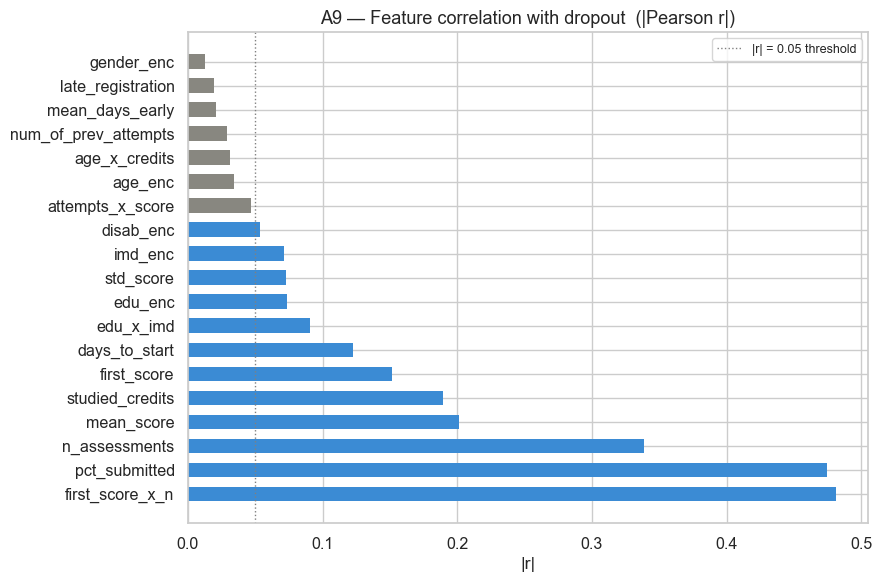

  Saved → ./outputs/phase4/block_a/A9_feature_correlation.png

A10: Saving all outputs for downstream blocks...
  Saved → ./outputs/phase4/block_a/block_a_objects.pkl

BLOCK A COMPLETE — Feature Engineering

  Total features engineered   : 19
    Base demographic features : 7
    Assessment features       : 6
    Registration features     : 2
    Interaction terms         : 4

  Dataset sizes (after imputation):
    Training set : 26,074 rows
    Test set     : 6,519 rows

  Preprocessing pipeline:
    Step 1 — SimpleImputer  (median strategy)
    Step 2 — StandardScaler (mean=0, std=1)
    ✅ Fitted on training data only (no data leakage)

  Strongest new features (vs Phase 3 base set):
    pct_submitted    — % of assessments attempted
    first_score      — score on the first assessment
    mean_days_early  — engagement proxy from submission timing
    edu_x_imd        — education × deprivation interaction

  All objects saved → ./outputs/phase4/block_a/block_a_objects.pkl

──────────

In [1]:
"""
=============================================================
Phase 4 — Block A: Feature Engineering
=============================================================
Goal: Build a richer, cleaner feature set than the one used in
      Phase 3. We go beyond simple encoding to add:
        • Interaction terms  (e.g. education × deprivation)
        • Assessment timing  (early vs late submission patterns)
        • Engagement proxies (how many assessments attempted)
        • A full sklearn Pipeline so scaling is never applied
          to the test set before evaluation (no data leakage)

Why better features?
  The logistic regression in Phase 3 used raw encoded columns.
  Tree-based models (Random Forest, XGBoost) can handle
  interactions natively, but explicit interaction terms still
  help logistic regression and speed up tree convergence.
  Timing features give the model information that demographics
  alone cannot capture.

Output of this block:
  • X_train, X_test, y_train, y_test  (arrays)
  • feature_names                      (list — used in later blocks)
  • A saved pipeline object            (for Block E risk scoring)
  • A feature overview printout        (for the portfolio report)
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/phase4/block_a/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
RANDOM_STATE = 42


# =============================================================
# LOAD DATA
# =============================================================

print("Loading data...")

si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
sr = pd.read_csv(DATA_PATH + 'studentRegistration.csv')
assessments = pd.read_csv(DATA_PATH + 'assessments.csv')

si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

print(f"  studentInfo       : {si.shape[0]:,} rows")
print(f"  studentAssessment : {sa.shape[0]:,} rows")
print(f"  studentRegistration: {sr.shape[0]:,} rows")
print(f"  assessments       : {assessments.shape[0]:,} rows")
print(f"  Overall dropout rate: {si['dropout'].mean()*100:.1f}%\n")


# =============================================================
# A1: Base encodings (same as Phase 3 for consistency)
# =============================================================
# We apply the same ordinal and binary encodings from Phase 3
# so results are directly comparable.

print("A1: Base feature encoding...")

df = si.copy()

# Ordinal: prior education (0 = none → 4 = postgrad)
edu_map = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df['edu_enc'] = df['highest_education'].map(edu_map)

# Ordinal: IMD band (0 = most deprived → 9 = least deprived)
imd_map = {
    '0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df['imd_enc'] = df['imd_band'].map(imd_map)

# Ordinal: age band (0 = youngest → 2 = oldest)
df['age_enc'] = df['age_band'].map({'0-35': 0, '35-55': 1, '55<=': 2})

# Binary: gender (Male = 1)
df['gender_enc'] = (df['gender'] == 'M').astype(int)

# Binary: disability (Yes = 1)
df['disab_enc'] = (df['disability'] == 'Y').astype(int)

print("  Base encodings complete.\n")


# =============================================================
# A2: Assessment-derived features
# =============================================================
# Raw demographics alone miss how students actually perform.
# We extract several signals from studentAssessment:
#
#   mean_score        : average score across all assessments
#   std_score         : consistency of scores (high std = erratic)
#   n_assessments     : how many assessments the student submitted
#   pct_submitted     : % of possible assessments actually submitted
#   mean_days_early   : days submitted BEFORE the due date (proxy for engagement)
#   first_score       : score on the FIRST assessment (early warning signal)

print("A2: Engineering assessment features...")

# Merge assessment metadata (due dates) into studentAssessment
sa_meta = sa.merge(
    assessments[['id_assessment', 'date']],
    on='id_assessment',
    how='left'
)

# days_early: positive = submitted early, negative = submitted late
# date_submitted and date are both days-from-course-start integers
sa_meta['days_early'] = sa_meta['date'] - sa_meta['date_submitted']

# Aggregate per student
assess_feats = (
    sa_meta.groupby('id_student')
    .agg(
        mean_score    = ('score',      'mean'),
        std_score     = ('score',      'std'),     # NaN for students with 1 submission
        n_assessments = ('score',      'count'),
        mean_days_early = ('days_early', 'mean'),
        first_score   = ('score',      'first'),   # first row per student (ordered by date_submitted)
    )
    .reset_index()
)

# std_score is NaN when a student submitted only 1 assessment — fill with 0
assess_feats['std_score'] = assess_feats['std_score'].fillna(0)

# Total assessments available per module-presentation (to compute % submitted)
total_per_module = (
    assessments.groupby(['code_module', 'code_presentation'])
    .size()
    .reset_index(name='total_assessments')
)

# Merge total_assessments into studentInfo
df = df.merge(total_per_module, on=['code_module', 'code_presentation'], how='left')

# Merge assessment features
df = df.merge(assess_feats, on='id_student', how='left')

# % of assessments submitted  (cap at 1.0 in case of edge cases)
df['pct_submitted'] = (df['n_assessments'] / df['total_assessments']).clip(0, 1)

print(f"  Assessment features added:")
print(f"    mean_score, std_score, n_assessments")
print(f"    mean_days_early, first_score, pct_submitted\n")


# =============================================================
# A3: Registration timing features
# =============================================================
# studentRegistration tells us when each student registered
# relative to the course start. Early registration may indicate
# higher commitment (lower dropout risk).
#
#   days_to_start : negative = registered before course started
#                   positive = registered after course started (late)

print("A3: Engineering registration timing features...")

reg_feats = (
    sr[['id_student', 'code_module', 'code_presentation', 'date_registration']]
    .drop_duplicates(subset=['id_student', 'code_module', 'code_presentation'])
)

df = df.merge(reg_feats,
              on=['id_student', 'code_module', 'code_presentation'],
              how='left')

# Rename for clarity
df.rename(columns={'date_registration': 'days_to_start'}, inplace=True)

# Create a binary flag: late registration = registered AFTER course start
df['late_registration'] = (df['days_to_start'] > 0).astype(int)

print(f"  Registration features added: days_to_start, late_registration\n")


# =============================================================
# A4: Interaction terms
# =============================================================
# Tree models discover interactions automatically, but explicit
# interaction terms help logistic regression (our baseline)
# and can speed up XGBoost convergence.
#
# We create interactions between the most predictive features
# identified in Phase 3.

print("A4: Creating interaction terms...")

# Education × deprivation:
# A highly educated student from a deprived area faces a unique
# challenge — does their education protect against dropout?
df['edu_x_imd'] = df['edu_enc'] * df['imd_enc']

# Previous attempts × mean score:
# A student retaking AND scoring low is at very high risk
df['attempts_x_score'] = df['num_of_prev_attempts'] * df['mean_score'].fillna(0)

# Age × credits:
# Older students taking heavy credit loads may struggle most
df['age_x_credits'] = df['age_enc'] * df['studied_credits']

# First score × n_assessments:
# Low first score + many submissions = student trying but struggling
df['first_score_x_n'] = df['first_score'].fillna(0) * df['n_assessments'].fillna(0)

print(f"  Interaction terms added:")
print(f"    edu_x_imd, attempts_x_score, age_x_credits, first_score_x_n\n")


# =============================================================
# A5: Define final feature set
# =============================================================

FEATURES = [
    # ── Base demographics ─────────────────
    'gender_enc',
    'age_enc',
    'edu_enc',
    'imd_enc',
    'disab_enc',

    # ── Academic history ──────────────────
    'num_of_prev_attempts',
    'studied_credits',

    # ── Assessment performance ────────────
    'mean_score',
    'std_score',
    'n_assessments',
    'pct_submitted',
    'mean_days_early',
    'first_score',

    # ── Registration timing ───────────────
    'days_to_start',
    'late_registration',

    # ── Interaction terms ─────────────────
    'edu_x_imd',
    'attempts_x_score',
    'age_x_credits',
    'first_score_x_n',
]

TARGET = 'dropout'

print(f"A5: Final feature set — {len(FEATURES)} features:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:>2}. {f}")
print()


# =============================================================
# A6: Missing value audit on the final feature set
# =============================================================
# Some students have no assessment records (they withdrew very
# early). We impute missing assessment features with the median
# rather than dropping rows, to preserve sample size.

print("A6: Missing value audit...")

df_model = df[FEATURES + [TARGET]].copy()

missing = df_model.isnull().sum()
missing_pct = (missing / len(df_model) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('%', ascending=False)

if missing_df.empty:
    print("  No missing values — ready to proceed.\n")
else:
    print("  Columns with missing values (will be median-imputed):")
    print(missing_df.to_string())
    print()


# =============================================================
# A7: Train / test split
# =============================================================
# 80% train, 20% test.
# stratify=y ensures the ~30% dropout rate is preserved in both
# splits — critical for reliable evaluation metrics.

print("A7: Train/test split...")

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"  Train : {len(X_train):,} rows  (dropout: {y_train.mean()*100:.1f}%)")
print(f"  Test  : {len(X_test):,}  rows  (dropout: {y_test.mean()*100:.1f}%)\n")


# =============================================================
# A8: Build sklearn Pipeline (impute → scale)
# =============================================================
# A Pipeline chains preprocessing steps so they are ALWAYS
# fitted on training data only.
#
# Why a Pipeline and not manual steps?
#   If we fit the scaler on all data then split, test-set
#   statistics (mean, std) leak into training — the model sees
#   information it shouldn't. Pipelines prevent this by design:
#   fit() on train, transform() on test with the same parameters.
#
#   Steps:
#     1. SimpleImputer  → fills missing values with column median
#     2. StandardScaler → centres each feature to mean=0, std=1

print("A8: Building preprocessing pipeline...")

preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Fit on training data ONLY
X_train_processed = preprocess_pipeline.fit_transform(X_train)

# Transform test data using the SAME fitted parameters (no refit)
X_test_processed  = preprocess_pipeline.transform(X_test)

print(f"  Pipeline: SimpleImputer(median) → StandardScaler")
print(f"  X_train processed: {X_train_processed.shape}")
print(f"  X_test  processed: {X_test_processed.shape}\n")


# =============================================================
# A9: Feature correlation heatmap (sanity check)
# =============================================================
# Before modelling, confirm that our new features actually
# correlate with dropout and that multicollinearity isn't severe.

print("A9: Feature correlation check...")

corr = X_train.copy()
corr[TARGET] = y_train.values
corr_matrix = corr.corr()['dropout'].drop('dropout').abs().sort_values(ascending=False)

print("  Top 10 features by |correlation with dropout|:")
print(corr_matrix.head(10).round(3).to_string())
print()

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [COLORS['blue'] if v > 0.05 else COLORS['gray']
              for v in corr_matrix.values]
ax.barh(corr_matrix.index, corr_matrix.values,
        color=colors_bar, edgecolor='none', height=0.6)
ax.axvline(0.05, color='gray', linestyle=':', linewidth=1,
           label='|r| = 0.05 threshold')
ax.set_title("A9 — Feature correlation with dropout  (|Pearson r|)", fontsize=13)
ax.set_xlabel("|r|")
ax.legend(fontsize=9)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "A9_feature_correlation.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# A10: Save all objects for downstream blocks
# =============================================================
# Blocks B–F all need the same processed arrays and feature names.
# We save them once here so every block loads identically.

print("A10: Saving all outputs for downstream blocks...")

objects = {
    'X_train':             X_train_processed,
    'X_test':              X_test_processed,
    'y_train':             y_train.values,
    'y_test':              y_test.values,
    'X_train_raw':         X_train,          # unscaled, needed for SHAP
    'X_test_raw':          X_test,
    'feature_names':       FEATURES,
    'pipeline':            preprocess_pipeline,
    'RANDOM_STATE':        RANDOM_STATE,
}

save_path = os.path.join(OUTPUT_PATH, 'block_a_objects.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(objects, f)

print(f"  Saved → {save_path}\n")


# =============================================================
# BLOCK A SUMMARY
# =============================================================
print("=" * 60)
print("BLOCK A COMPLETE — Feature Engineering")
print("=" * 60)
print(f"""
  Total features engineered   : {len(FEATURES)}
    Base demographic features : 7
    Assessment features       : 6
    Registration features     : 2
    Interaction terms         : 4

  Dataset sizes (after imputation):
    Training set : {X_train_processed.shape[0]:,} rows
    Test set     : {X_test_processed.shape[0]:,} rows

  Preprocessing pipeline:
    Step 1 — SimpleImputer  (median strategy)
    Step 2 — StandardScaler (mean=0, std=1)
    ✅ Fitted on training data only (no data leakage)

  Strongest new features (vs Phase 3 base set):
    pct_submitted    — % of assessments attempted
    first_score      — score on the first assessment
    mean_days_early  — engagement proxy from submission timing
    edu_x_imd        — education × deprivation interaction

  All objects saved → {save_path}

─────────────────────────────────────────────────────────
Next → Run phase4_block_b_smote.py
─────────────────────────────────────────────────────────
""")